# Toy Retrieval Stress Test

목표: retrieved 후보 30개 중 3개만 유사하고 27개는 불필요한 경우, top_k=10으로 강제로 참고하게 했을 때 Dualhead가 노이즈를 덜 사용하게 되는지 살펴봅니다.

- Baseline: `ChronosBolt.py`
- Ours: `ChronosBolt_TabPFN_dualhead.py`
- Checkpoints (기존 위치 활용):
  - Baseline: `./checkpoints/pretrain_Chronos_lb512_Z_k20`
  - Dualhead: `./checkpoints/pretrain_Chronos_lb512_X-cosine-norm_k20_TabPFN_dualhead_l0.5`

이 노트북은 `motivation/` 폴더 안에서만 새 파일을 생성하며, 기존 코드를 수정하지 않습니다.


In [1]:
#os.getcwd()

In [2]:
import os, math, json, random
import numpy as np
import torch
from pathlib import Path

# Reproducibility
np.random.seed(0)
torch.manual_seed(0)

torch.set_float32_matmul_precision("high")
os.chdir('/home/seunghan.lee/workspace/ts-rag/motivation/')
# Paths
#ROOT = Path(__file__).resolve().parent.parent  # project root (ts-rag/ts-rag)
ROOT = Path('ts-rag/').resolve().parent.parent  # project root (ts-rag/ts-rag)
MOTI = ROOT / "motivation"
DATA_DIR = MOTI / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE_CONFIG_DIR = ROOT / "checkpoints" / "base"
#BASELINE_CKPT_DIR = ROOT / "checkpoints" / "pretrain_Chronos_lb512_Z_k20"
BASELINE_CKPT_DIR = ROOT / "old_checkpoints" / "checkpoints" / "pretrain_Chronos_lb512_Z_k5"

DUALHEAD_CKPT_DIR = ROOT / "checkpoints" / "pretrain_Chronos_lb512_X-cosine-norm_k15_TabPFN_dualhead_R_as_key_l0.7"
# DUALHEAD_CKPT_DIR = ROOT / "old_checkpoints" / "checkpoints" / "pretrain_Chronos_lb512_X-cosine-norm_k20_TabPFN_dualhead_l0.5"
BASELINE_CKPT = BASELINE_CKPT_DIR / "best.pth"
DUALHEAD_CKPT = DUALHEAD_CKPT_DIR / "best.pth"

assert BASE_CONFIG_DIR.exists(), f"Missing base config at {BASE_CONFIG_DIR}"
assert BASELINE_CKPT.exists(), f"Missing baseline ckpt at {BASELINE_CKPT}"
assert DUALHEAD_CKPT.exists(), f"Missing dualhead ckpt at {DUALHEAD_CKPT}"

# Hyperparams
context_len = 512
pred_len = 64
# retrieval control
num_candidates = 30  # N: total pool
k_top = 10           # K: number picked for retrieval
k_sim_top = 3        # k: how many of the picked top_k should be similar
k_dis_top = k_top - k_sim_top

# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device


device(type='cuda', index=0)

In [3]:
# Helper: richer waveform generator (trend + multi-harmonic + noise + regime shifts)

rng = np.random.default_rng(0)

def make_base_wave(length, freq=1/64, phase=0.0, amp=1.0, noise=0.01, trend=0.0, regime=None, rng=None):
    t = np.arange(length)
    sig = amp * np.sin(2 * math.pi * freq * t + phase)
    sig += 0.3 * amp * np.sin(2 * math.pi * (freq * 2) * t + phase * 1.3)  # 2nd harmonic
    sig += 0.15 * amp * np.sin(2 * math.pi * (freq * 3.2) * t + phase * 0.7)  # 3rd-ish harmonic
    sig += trend * t  # gentle trend
    if rng is None:
        sig += np.random.normal(scale=noise, size=length)
    else:
        sig += rng.normal(scale=noise, size=length)
    if regime is not None:
        for (start, end, delta) in regime:
            sig[start:end] += delta
    return sig.astype(np.float32)

def make_query_series(rng):
    q_freq = rng.uniform(1/240, 1/200)
    q_trend = rng.uniform(5e-4, 1.2e-3)
    q_phase = rng.uniform(0.0, 0.5)
    q_noise = rng.uniform(0.015, 0.03)
    q_regime = [
        (rng.integers(180, 240), rng.integers(240, 280), rng.uniform(0.08, 0.2)),
        (rng.integers(500, 540), rng.integers(540, 560), rng.uniform(-0.14, -0.05)),
    ]
    q_full = make_base_wave(
        context_len + pred_len,
        freq=q_freq,
        phase=q_phase,
        amp=1.0,
        noise=q_noise,
        trend=q_trend,
        regime=q_regime,
        rng=rng,
    )
    return q_full, q_freq, q_trend

def synth_candidate(idx, label, q_freq, q_trend, rng):
    length = context_len + pred_len
    if label == "similar":
        # make "similar" but meaningfully different: much wider ranges
        freq = q_freq * rng.uniform(0.4, 1.6)
        phase = rng.uniform(0.0, 2 * math.pi)
        amp = rng.uniform(0.6, 1.4)
        trend = q_trend * (1 + rng.uniform(-2.0, 2.0))
        noise = rng.uniform(0.06, 0.12)
        regime = [
            (rng.integers(150, 260), rng.integers(240, 340), rng.uniform(0.0, 0.24)),
            (rng.integers(460, 580), rng.integers(540, 620), rng.uniform(-0.22, 0.02)),
        ]
        seq = make_base_wave(length, freq=freq, phase=phase, amp=amp, noise=noise, trend=trend, regime=regime, rng=rng)
        seq += rng.normal(scale=0.04, size=length)  # extra roughness
    else:
        # diverse dissimilar patterns (wider freq span + extra style)
        style = rng.choice(["high_freq", "saw", "burst", "exp", "low_freq", "spike"])
        base_freq = {
            "high_freq": rng.uniform(1/20, 1/10),
            "low_freq": rng.uniform(1/1400, 1/600),
            "saw": rng.uniform(1/60, 1/24),
            "burst": rng.uniform(1/120, 1/50),
            "exp": rng.uniform(1/120, 1/60),
            "spike": rng.uniform(1/200, 1/120),
        }[style]
        amp = rng.uniform(0.25, 1.3)
        phase = rng.uniform(0, 2 * math.pi)
        trend = rng.uniform(-3e-3, 3e-3)
        noise = rng.uniform(0.05, 0.12)
        regime = [
            (rng.integers(100, 220), rng.integers(220, 300), rng.uniform(-0.45, 0.45)),
            (rng.integers(340, 460), rng.integers(460, 560), rng.uniform(-0.4, 0.4)),
        ]
        seq = make_base_wave(length, freq=base_freq, phase=phase, amp=amp, noise=noise, trend=trend, regime=regime, rng=rng)
        # add style-specific components
        t = np.arange(length)
        if style == "saw":
            seq += 0.4 * ((t + rng.integers(0, 20)) % 64) / 64
        if style == "burst":
            seq += np.sign(np.sin(t / rng.uniform(3.0, 7.5) + idx)) * 0.5
        if style == "exp":
            seq += np.exp(np.linspace(0, 1, length)) * rng.uniform(0.04, 0.1)
        if style == "high_freq":
            seq += 0.3 * np.sin(2 * math.pi * t * rng.uniform(1/8, 1/5) + rng.uniform(0, 1))
        if style == "low_freq":
            seq += 0.6 * np.sin(2 * math.pi * t * rng.uniform(1/1500, 1/800))
        if style == "spike":
            spikes = (rng.integers(0, 30, size=length) == 0).astype(np.float32)
            seq += spikes * rng.uniform(0.3, 0.8)
    return seq.astype(np.float32)

def build_candidate_bank(num_candidates, k_sim_top, k_dis_top, q_freq, q_trend, rng):
    # ensure we have enough similar/dissimilar pool to select from
    sim_pool = max(k_sim_top + 2, num_candidates // 3)
    sim_pool = min(sim_pool, num_candidates - k_dis_top)  # keep room for dissimilar
    dis_pool = num_candidates - sim_pool
    retrieved = []
    labels = []
    for i in range(sim_pool):
        retrieved.append(synth_candidate(i, "similar", q_freq, q_trend, rng))
        labels.append("similar")
    for i in range(dis_pool):
        retrieved.append(synth_candidate(i + sim_pool, "dissimilar", q_freq, q_trend, rng))
        labels.append("dissimilar")
    return np.stack(retrieved, axis=0), np.array(labels)

def enforce_topk_mix(query_ctx, retrieved, labels, k_top, k_sim_top, rng):
    def l2_dist(a, b):
        return np.linalg.norm(a - b)

    dists = np.array([l2_dist(query_ctx, seq[:context_len]) for seq in retrieved], dtype=np.float32)
    sim_idx = np.where(labels == "similar")[0]
    dis_idx = np.where(labels == "dissimilar")[0]

    sim_sorted = sim_idx[np.argsort(dists[sim_idx])]
    dis_sorted = dis_idx[np.argsort(dists[dis_idx])]

    keep_sim = sim_sorted[:k_sim_top]
    keep_dis = dis_sorted[: (k_top - k_sim_top)]

    penalty = 1e3
    bias = np.zeros_like(dists)
    bias[np.setdiff1d(sim_idx, keep_sim, assume_unique=True)] = penalty
    bias[np.setdiff1d(dis_idx, keep_dis, assume_unique=True)] = penalty

    dists_adj = dists + bias + rng.normal(scale=0.01, size=dists.shape)

    top_idx = np.argsort(dists_adj)[:k_top]
    top_dists = dists_adj[top_idx]
    top_retrieved = retrieved[top_idx]
    top_labels = labels[top_idx]
    return dists_adj, top_idx, top_dists, top_retrieved, top_labels

# Build query and candidates
query_full, q_freq, q_trend = make_query_series(rng)
query_context = query_full[:context_len]
query_target = query_full[context_len:]

retrieved, labels = build_candidate_bank(num_candidates, k_sim_top, k_dis_top, q_freq, q_trend, rng)

full_dists, top_idx, top_dists, top_retrieved, top_labels = enforce_topk_mix(
    query_context, retrieved, labels, k_top, k_sim_top, rng
)

np.save(DATA_DIR / "retrieved.npy", retrieved)
np.save(DATA_DIR / "labels.npy", labels)
np.save(DATA_DIR / "query_context.npy", query_context)
np.save(DATA_DIR / "query_target.npy", query_target)
np.save(DATA_DIR / "top_indices.npy", top_idx)

retrieved.shape, labels.tolist()[:5]


((30, 576), ['similar', 'similar', 'similar', 'similar', 'similar'])

In [4]:
# Model-specific retrieval selection: baseline (latent space) vs ours (data space)
# We override top-k selections for downstream steps.

def select_topk_mix_with_dists(dists, labels, k_top, k_sim_top, rng):
    sim_idx = np.where(labels == "similar")[0]
    dis_idx = np.where(labels == "dissimilar")[0]
    sim_sorted = sim_idx[np.argsort(dists[sim_idx])]
    dis_sorted = dis_idx[np.argsort(dists[dis_idx])]
    keep_sim = sim_sorted[:k_sim_top]
    keep_dis = dis_sorted[: (k_top - k_sim_top)]
    penalty = 1e3
    bias = np.zeros_like(dists)
    bias[np.setdiff1d(sim_idx, keep_sim, assume_unique=True)] = penalty
    bias[np.setdiff1d(dis_idx, keep_dis, assume_unique=True)] = penalty
    dists_adj = dists + bias + rng.normal(scale=0.01, size=dists.shape)
    top_idx = np.argsort(dists_adj)[:k_top]
    top_dists = dists_adj[top_idx]
    return dists_adj, top_idx, top_dists

retr_ctx = retrieved[:, :context_len]

# helper: min-max normalize to [0,1] per series
def minmax_norm(x, axis=-1, eps=1e-6):
    x_min = x.min(axis=axis, keepdims=True)
    x_max = x.max(axis=axis, keepdims=True)
    denom = np.where((x_max - x_min) < eps, 1.0, x_max - x_min)
    return (x - x_min) / denom

# data-space distances (ours): min-max normalize then cosine similarity
query_ctx_norm = minmax_norm(query_context[None, :])[0]
retr_ctx_norm = minmax_norm(retr_ctx)
query_norm = np.linalg.norm(query_ctx_norm) + 1e-8
retr_norm = np.linalg.norm(retr_ctx_norm, axis=1) + 1e-8
cos_sim = (retr_ctx_norm @ query_ctx_norm) / (retr_norm * query_norm)
dists_data = -cos_sim  # smaller is better

# latent-space distances (baseline): random projection as a toy latent space
proj = rng.normal(scale=1/np.sqrt(context_len), size=(context_len, 64))
query_lat = query_context @ proj
retr_lat = retr_ctx @ proj
dists_latent = np.linalg.norm(retr_lat - query_lat[None, :], axis=1)

full_dists_base, top_idx_base, top_dists_base = select_topk_mix_with_dists(dists_latent, labels, k_top, k_sim_top, rng)
full_dists_ours, top_idx_ours, top_dists_ours = select_topk_mix_with_dists(dists_data, labels, k_top, k_sim_top, rng)

top_retrieved_base = retrieved[top_idx_base]
top_labels_base = labels[top_idx_base]

top_retrieved_ours = retrieved[top_idx_ours]
top_labels_ours = labels[top_idx_ours]

top_idx = top_idx_ours
top_dists = top_dists_ours
top_retrieved = top_retrieved_ours
top_labels = top_labels_ours

# save ours selection as default artifacts
np.save(DATA_DIR / "top_indices.npy", top_idx_ours)



In [5]:
# Top-k selection summary
from collections import Counter

print("Top-k (ours/data-space) label counts:", dict(Counter(top_labels_ours.tolist())))
print("Top-k (ours) top-5 distances:", top_dists_ours[:5])
print("Top-k (ours) indices:", top_idx_ours.tolist())
print("Top-k (baseline/latent-space) label counts:", dict(Counter(top_labels_base.tolist())))
print("Top-k (baseline) top-5 distances:", top_dists_base[:5])
print("Top-k (baseline) indices:", top_idx_base.tolist())


Top-k (ours/data-space) label counts: {'similar': 3, 'dissimilar': 7}
Top-k (ours) top-5 distances: [-0.90844435 -0.86314111 -0.85029825 -0.84127682 -0.83662394]
Top-k (ours) indices: [5, 18, 29, 7, 8, 16, 25, 17, 20, 12]
Top-k (baseline/latent-space) label counts: {'similar': 3, 'dissimilar': 7}
Top-k (baseline) top-5 distances: [5.32549799 5.83124621 6.58586981 6.84779028 6.98220787]
Top-k (baseline) indices: [5, 11, 27, 8, 23, 6, 12, 10, 13, 16]


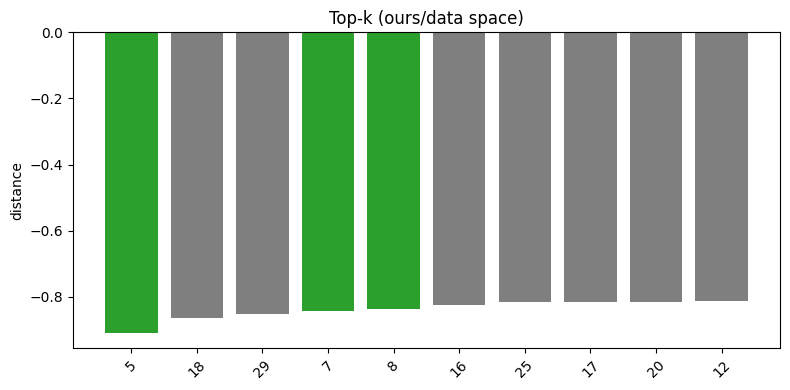

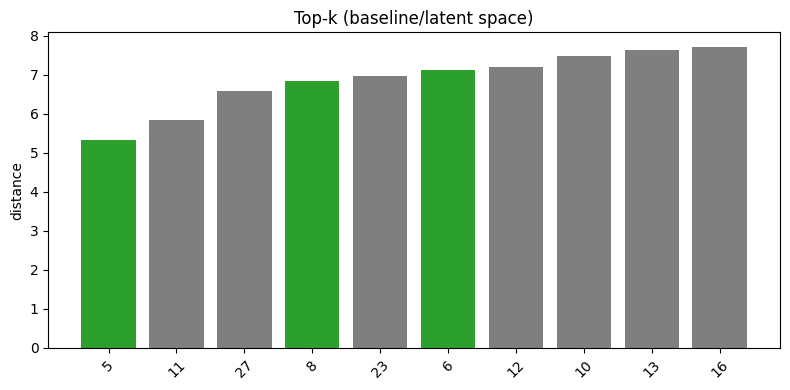

Top-k (ours) indices (sorted): [5, 18, 29, 7, 8, 16, 25, 17, 20, 12]
Top-k (ours) labels (sorted): ['similar', 'dissimilar', 'dissimilar', 'similar', 'similar', 'dissimilar', 'dissimilar', 'dissimilar', 'dissimilar', 'dissimilar']
Top-k (baseline) indices (sorted): [5, 11, 27, 8, 23, 6, 12, 10, 13, 16]
Top-k (baseline) labels (sorted): ['similar', 'dissimilar', 'dissimilar', 'similar', 'dissimilar', 'similar', 'dissimilar', 'dissimilar', 'dissimilar', 'dissimilar']


In [6]:
# Visualize which indices got into top-k (ours vs baseline)
import matplotlib.pyplot as plt

# ours order
order_ours = np.argsort(top_dists_ours)
colors_ours = ["tab:green" if lbl=="similar" else "tab:gray" for lbl in top_labels_ours[order_ours]]
plt.figure(figsize=(8,4))
plt.bar(range(k_top), top_dists_ours[order_ours], color=colors_ours)
plt.xticks(range(k_top), top_idx_ours[order_ours], rotation=45)
plt.ylabel("distance")
plt.title("Top-k (ours/data space)")
plt.tight_layout()
plt.show()

# baseline order
order_base = np.argsort(top_dists_base)
colors_base = ["tab:green" if lbl=="similar" else "tab:gray" for lbl in top_labels_base[order_base]]
plt.figure(figsize=(8,4))
plt.bar(range(k_top), top_dists_base[order_base], color=colors_base)
plt.xticks(range(k_top), top_idx_base[order_base], rotation=45)
plt.ylabel("distance")
plt.title("Top-k (baseline/latent space)")
plt.tight_layout()
plt.show()

print("Top-k (ours) indices (sorted):", top_idx_ours[order_ours].tolist())
print("Top-k (ours) labels (sorted):", top_labels_ours[order_ours].tolist())
print("Top-k (baseline) indices (sorted):", top_idx_base[order_base].tolist())
print("Top-k (baseline) labels (sorted):", top_labels_base[order_base].tolist())


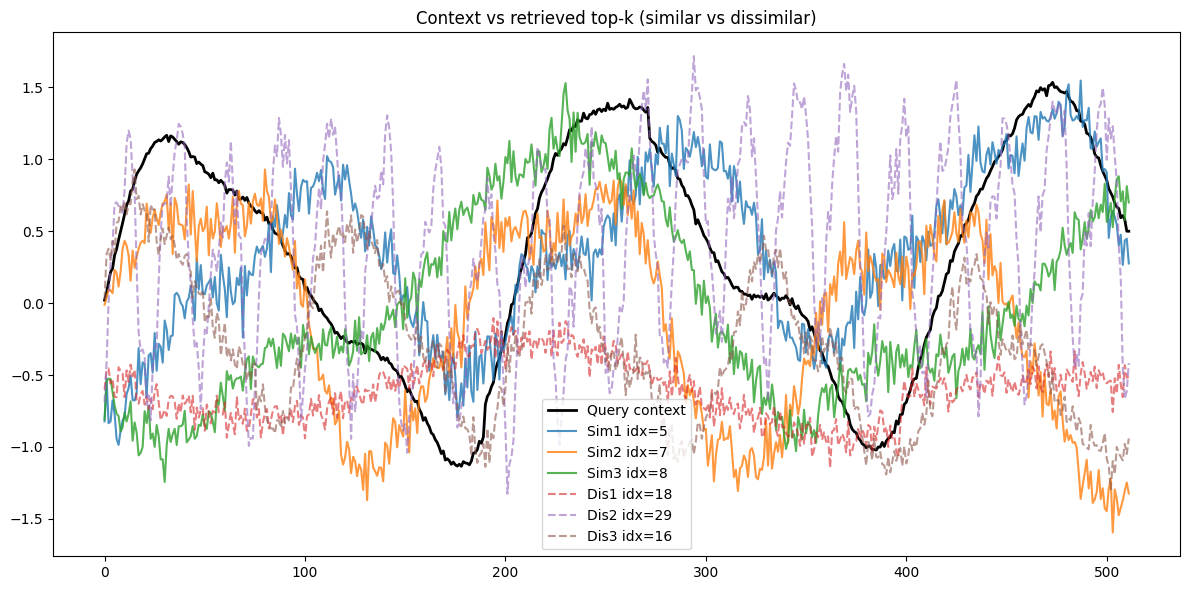

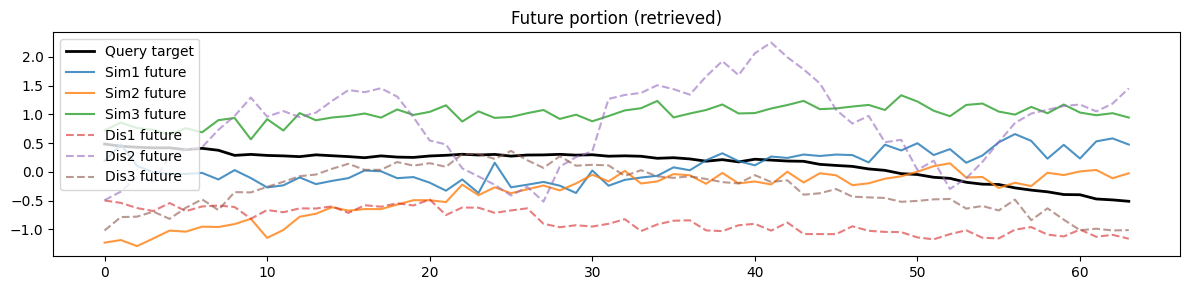

In [7]:
# Plot retrieved sequences: top 3 similar and top 3 dissimilar (by distance)
import matplotlib.pyplot as plt

# order top_k by distance
order = np.argsort(top_dists)
ordered_idx = top_idx[order]
ordered_labels = top_labels[order]
ordered_series = top_retrieved[order]

sim_positions = [i for i,lbl in enumerate(ordered_labels) if lbl == 'similar'][:3]
dis_positions = [i for i,lbl in enumerate(ordered_labels) if lbl == 'dissimilar'][:3]

plt.figure(figsize=(12, 6))
plt.plot(query_context, label='Query context', color='black', linewidth=2)
for j, pos in enumerate(sim_positions):
    plt.plot(ordered_series[pos, :context_len], label=f'Sim{j+1} idx={ordered_idx[pos]}', alpha=0.8)
for j, pos in enumerate(dis_positions):
    plt.plot(ordered_series[pos, :context_len], label=f'Dis{j+1} idx={ordered_idx[pos]}', alpha=0.6, linestyle='--')
plt.title('Context vs retrieved top-k (similar vs dissimilar)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(query_target, label='Query target', color='black', linewidth=2)
for j, pos in enumerate(sim_positions):
    plt.plot(ordered_series[pos, context_len:], label=f'Sim{j+1} future', alpha=0.8)
for j, pos in enumerate(dis_positions):
    plt.plot(ordered_series[pos, context_len:], label=f'Dis{j+1} future', alpha=0.6, linestyle='--')
plt.title('Future portion (retrieved)')
plt.legend()
plt.tight_layout()
plt.show()



In [8]:
# Tensors for model inputs
context_t = torch.tensor(query_context, dtype=torch.float32, device=device).unsqueeze(0)
target_t = torch.tensor(query_target, dtype=torch.float32, device=device).unsqueeze(0)
mask_t = torch.ones_like(context_t)
target_mask_t = torch.ones_like(target_t)

retrieved_t_base = torch.tensor(top_retrieved_base, dtype=torch.float32, device=device).unsqueeze(0)
distances_t_base = torch.tensor(top_dists_base, dtype=torch.float32, device=device).unsqueeze(0)

retrieved_t_ours = torch.tensor(top_retrieved_ours, dtype=torch.float32, device=device).unsqueeze(0)
distances_t_ours = torch.tensor(top_dists_ours, dtype=torch.float32, device=device).unsqueeze(0)

retrieved_t_ours.shape, distances_t_ours.shape


(torch.Size([1, 10, 576]), torch.Size([1, 10]))

In [9]:
import sys
sys.path.append(str(ROOT))

from transformers import AutoConfig
from models.ChronosBolt import ChronosBoltModelForForecastingWithRetrieval as ChronosBoltModelForForecastingWithRetrieval_base
from models.ChronosBolt_TabPFN_dualhead_R_as_key import ChronosBoltModelForForecastingWithRetrieval as ChronosBoltModelForForecastingWithRetrieval_ours


def load_model(ckpt_file: Path, cls, augment: str | None = None):
    # Use base config; load weights from the given checkpoint
    cfg = AutoConfig.from_pretrained(BASE_CONFIG_DIR, trust_remote_code=True)
    state = torch.load(ckpt_file, map_location=device)
    extra = {"augment": augment} if augment is not None else {}
    model = cls.from_pretrained(BASE_CONFIG_DIR, config=cfg, state_dict=state, **extra)
    return model.to(device).eval()

baseline_model = load_model(BASELINE_CKPT, ChronosBoltModelForForecastingWithRetrieval_base, augment="moe")
dualhead_model = load_model(DUALHEAD_CKPT, ChronosBoltModelForForecastingWithRetrieval_ours, augment="moe")

baseline_model.__class__.__name__, dualhead_model.__class__.__name__


self.chronos_config.context_length 2048


('ChronosBoltModelForForecastingWithRetrieval',
 'ChronosBoltModelForForecastingWithRetrieval')

In [10]:
@torch.no_grad()
def run_model(model, context_t, target_t, mask_t, target_mask_t, retrieved_t, distances_t):
    # mimic zeroshot.py behavior: target_mask None to avoid bool ops on float
    out = model(
        context=context_t,
        mask=mask_t,
        target=target_t,
        target_mask=None,
        retrieved_seq=retrieved_t,
        distances=distances_t,
    )
    pred = out.quantile_preds.squeeze(0).mean(0)  # mean over quantiles
    mse = ((pred - target_t.squeeze(0)) ** 2).mean().item()
    return pred.cpu().numpy(), mse

base_pred, base_mse = run_model(baseline_model, context_t, target_t, mask_t, target_mask_t, retrieved_t_base, distances_t_base)
dual_pred, dual_mse = run_model(dualhead_model, context_t, target_t, mask_t, target_mask_t, retrieved_t_ours, distances_t_ours)

{"baseline_mse": base_mse, "dualhead_mse": dual_mse}


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


{'baseline_mse': 0.08041948080062866, 'dualhead_mse': 0.12158476561307907}

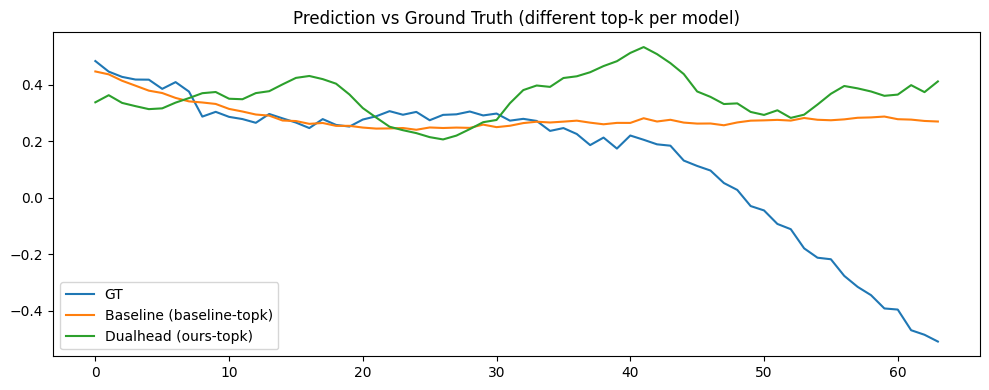

Top-10 label counts (ours selection): {'dissimilar': 7, 'similar': 3}
Top-10 label counts (baseline selection): {'dissimilar': 7, 'similar': 3}


In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
t = np.arange(pred_len)
plt.plot(t, query_target, label="GT")
plt.plot(t, base_pred, label="Baseline (baseline-topk)")
plt.plot(t, dual_pred, label="Dualhead (ours-topk)")
plt.title("Prediction vs Ground Truth (different top-k per model)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Top-{k_top} label counts (ours selection):", {k:int(v) for k,v in zip(*np.unique(top_labels_ours, return_counts=True))})
print(f"Top-{k_top} label counts (baseline selection):", {k:int(v) for k,v in zip(*np.unique(top_labels_base, return_counts=True))})


In [12]:
# Sweep multiple synthetic seeds to find a case where dualhead >> baseline
# We keep N, k, and mix constraints fixed; only RNG varies.

from collections import namedtuple

Case = namedtuple("Case", [
    "seed", "base_mse", "dual_mse", "improve",
    "query_context", "query_target",
    "top_idx", "top_dists", "top_retrieved", "top_labels",
    "retrieved", "labels",
])

def build_case(seed):
    rng_local = np.random.default_rng(seed)
    query_full, q_freq, q_trend = make_query_series(rng_local)
    query_context = query_full[:context_len]
    query_target = query_full[context_len:]

    retrieved, labels = build_candidate_bank(num_candidates, k_sim_top, k_dis_top, q_freq, q_trend, rng_local)
    full_dists, top_idx, top_dists, top_retrieved, top_labels = enforce_topk_mix(
        query_context, retrieved, labels, k_top, k_sim_top, rng_local
    )

    # tensors
    context_t = torch.tensor(query_context, dtype=torch.float32, device=device).unsqueeze(0)
    target_t = torch.tensor(query_target, dtype=torch.float32, device=device).unsqueeze(0)
    mask_t = torch.ones_like(context_t)
    target_mask_t = torch.ones_like(target_t)
    retrieved_t = torch.tensor(top_retrieved, dtype=torch.float32, device=device).unsqueeze(0)
    distances_t = torch.tensor(top_dists, dtype=torch.float32, device=device).unsqueeze(0)

    base_pred, base_mse = run_model(baseline_model, context_t, target_t, mask_t, target_mask_t, retrieved_t, distances_t)
    dual_pred, dual_mse = run_model(dualhead_model, context_t, target_t, mask_t, target_mask_t, retrieved_t, distances_t)

    improve = base_mse - dual_mse
    return Case(seed, base_mse, dual_mse, improve,
                query_context, query_target,
                top_idx, top_dists, top_retrieved, top_labels,
                retrieved, labels), base_pred, dual_pred

best_pos = None  # cases where dualhead beats baseline
best_pos_base_pred = None
best_pos_dual_pred = None
best_neg = None  # fallback if none beat baseline
best_neg_base_pred = None
best_neg_dual_pred = None

for seed in [78]:
    case, bpred, dpred = build_case(seed)
    if case.improve > 0:
        if (best_pos is None) or (case.dual_mse < best_pos.dual_mse - 1e-6):
            best_pos = case
            best_pos_base_pred = bpred
            best_pos_dual_pred = dpred
    else:
        if (best_neg is None) or (case.improve > best_neg.improve):
            best_neg = case
            best_neg_base_pred = bpred
            best_neg_dual_pred = dpred

if best_pos is not None:
    best = best_pos
    best_base_pred = best_pos_base_pred
    best_dual_pred = best_pos_dual_pred
else:
    best = best_neg
    best_base_pred = best_neg_base_pred
    best_dual_pred = best_neg_dual_pred

print(f"Best seed: {best.seed}, improvement (baseline - dualhead) = {best.improve:.4f}")
print({"baseline_mse": best.base_mse, "dualhead_mse": best.dual_mse})

# Override globals for downstream plotting
query_context = best.query_context
query_target = best.query_target
top_idx = best.top_idx
top_dists = best.top_dists
top_retrieved = best.top_retrieved
top_labels = best.top_labels
retrieved = best.retrieved
labels = best.labels
base_pred = best_base_pred
dual_pred = best_dual_pred

# tensors for later reuse
context_t = torch.tensor(query_context, dtype=torch.float32, device=device).unsqueeze(0)
target_t = torch.tensor(query_target, dtype=torch.float32, device=device).unsqueeze(0)
mask_t = torch.ones_like(context_t)
target_mask_t = torch.ones_like(target_t)
retrieved_t = torch.tensor(top_retrieved, dtype=torch.float32, device=device).unsqueeze(0)
distances_t = torch.tensor(top_dists, dtype=torch.float32, device=device).unsqueeze(0)

# 1722

Best seed: 78, improvement (baseline - dualhead) = 0.0427
{'baseline_mse': 0.04653361812233925, 'dualhead_mse': 0.003868733299896121}


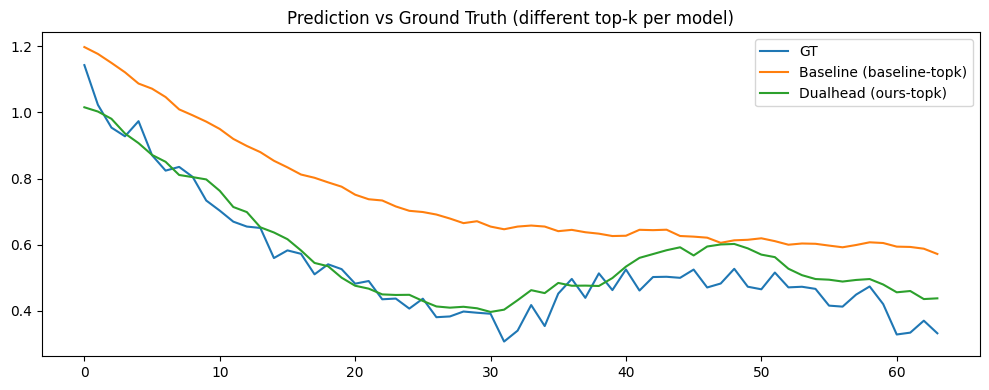

Top-10 label counts (ours selection): {'dissimilar': 7, 'similar': 3}
Top-10 label counts (baseline selection): {'dissimilar': 7, 'similar': 3}


In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
t = np.arange(pred_len)
plt.plot(t, query_target, label="GT")
plt.plot(t, base_pred, label="Baseline (baseline-topk)")
plt.plot(t, dual_pred, label="Dualhead (ours-topk)")
plt.title("Prediction vs Ground Truth (different top-k per model)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Top-{k_top} label counts (ours selection):", {k:int(v) for k,v in zip(*np.unique(top_labels_ours, return_counts=True))})
print(f"Top-{k_top} label counts (baseline selection):", {k:int(v) for k,v in zip(*np.unique(top_labels_base, return_counts=True))})


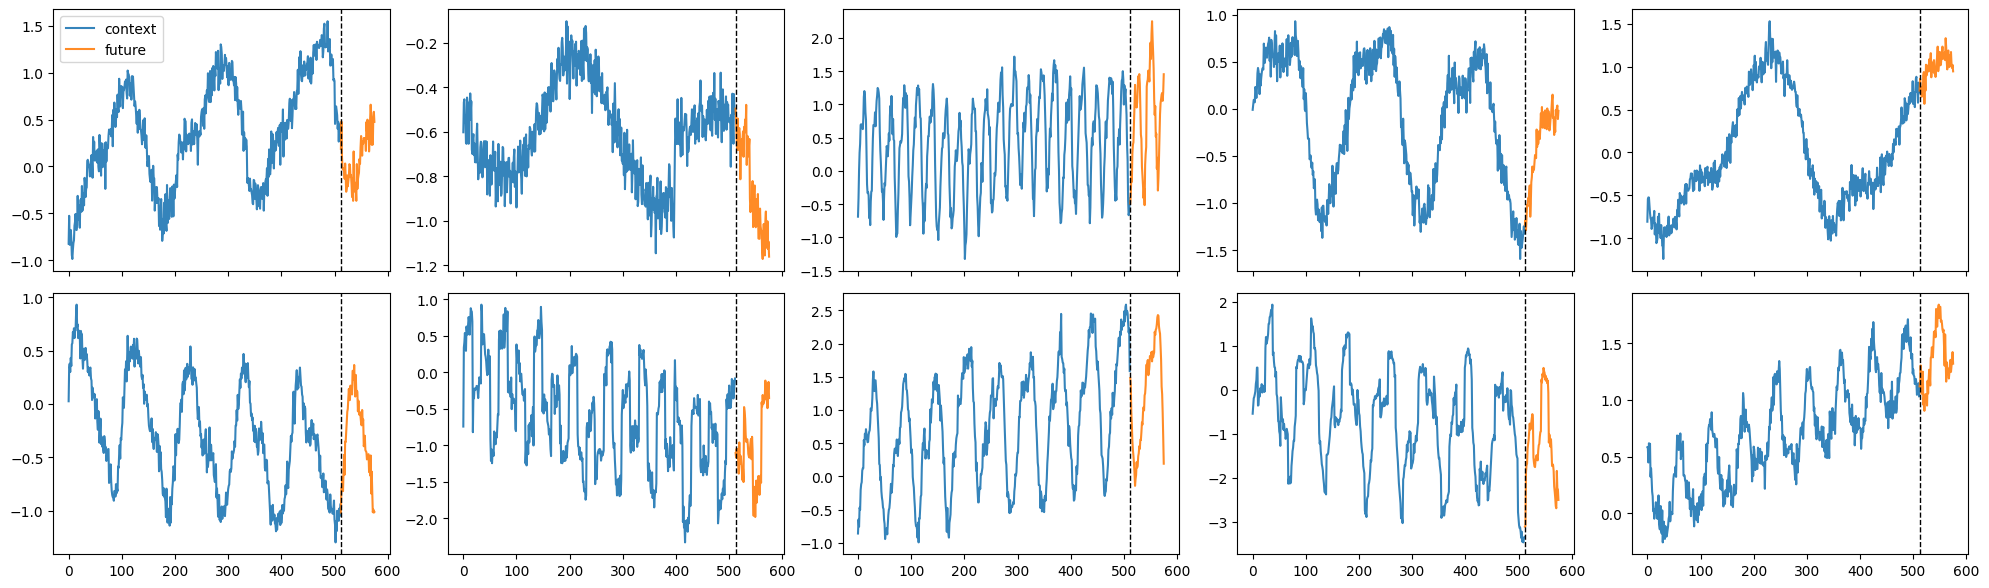

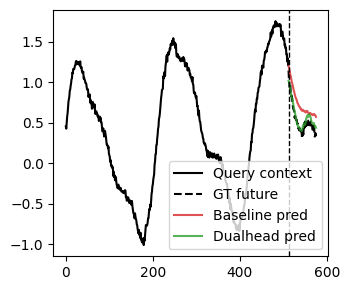

In [14]:
# Visualize retrieved top-k samples (ours selection)
rows, cols = 2, (k_top + 1) // 2
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows), sharex=True)
axes = axes.flatten()
for i in range(k_top):
    ax = axes[i]
    series = top_retrieved_ours[i]
    lbl = top_labels_ours[i]
    ax.plot(series[:context_len], color='tab:blue', alpha=0.9, label='context')
    ax.plot(np.arange(context_len, context_len + pred_len), series[context_len:], color='tab:orange', alpha=0.9, label='future')
    ax.axvline(context_len, color='k', linestyle='--', linewidth=1)
    #ax.set_title(f"idx={top_idx_ours[i]} ({lbl})")
    if i == 0:
        ax.legend()
# hide unused axes if any
for j in range(k_top, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

# Query + predictions (baseline vs dualhead) in one view
plt.figure(figsize=(3.6, 3))
full_t = np.arange(context_len + pred_len)
plt.plot(full_t[:context_len], query_context, label="Query context", color="black")
plt.plot(full_t[context_len:], query_target, label="GT future", color="black", linestyle="--")
plt.plot(full_t[context_len:], base_pred, label="Baseline pred", color="tab:red", alpha=0.8)
plt.plot(full_t[context_len:], dual_pred, label="Dualhead pred", color="tab:green", alpha=0.8)
plt.axvline(context_len, color="k", linestyle="--", linewidth=1)
#plt.title("Query & Predictions (different top-k per model)")
plt.legend()
plt.tight_layout()
plt.show()




In [15]:
################
##############33
###############

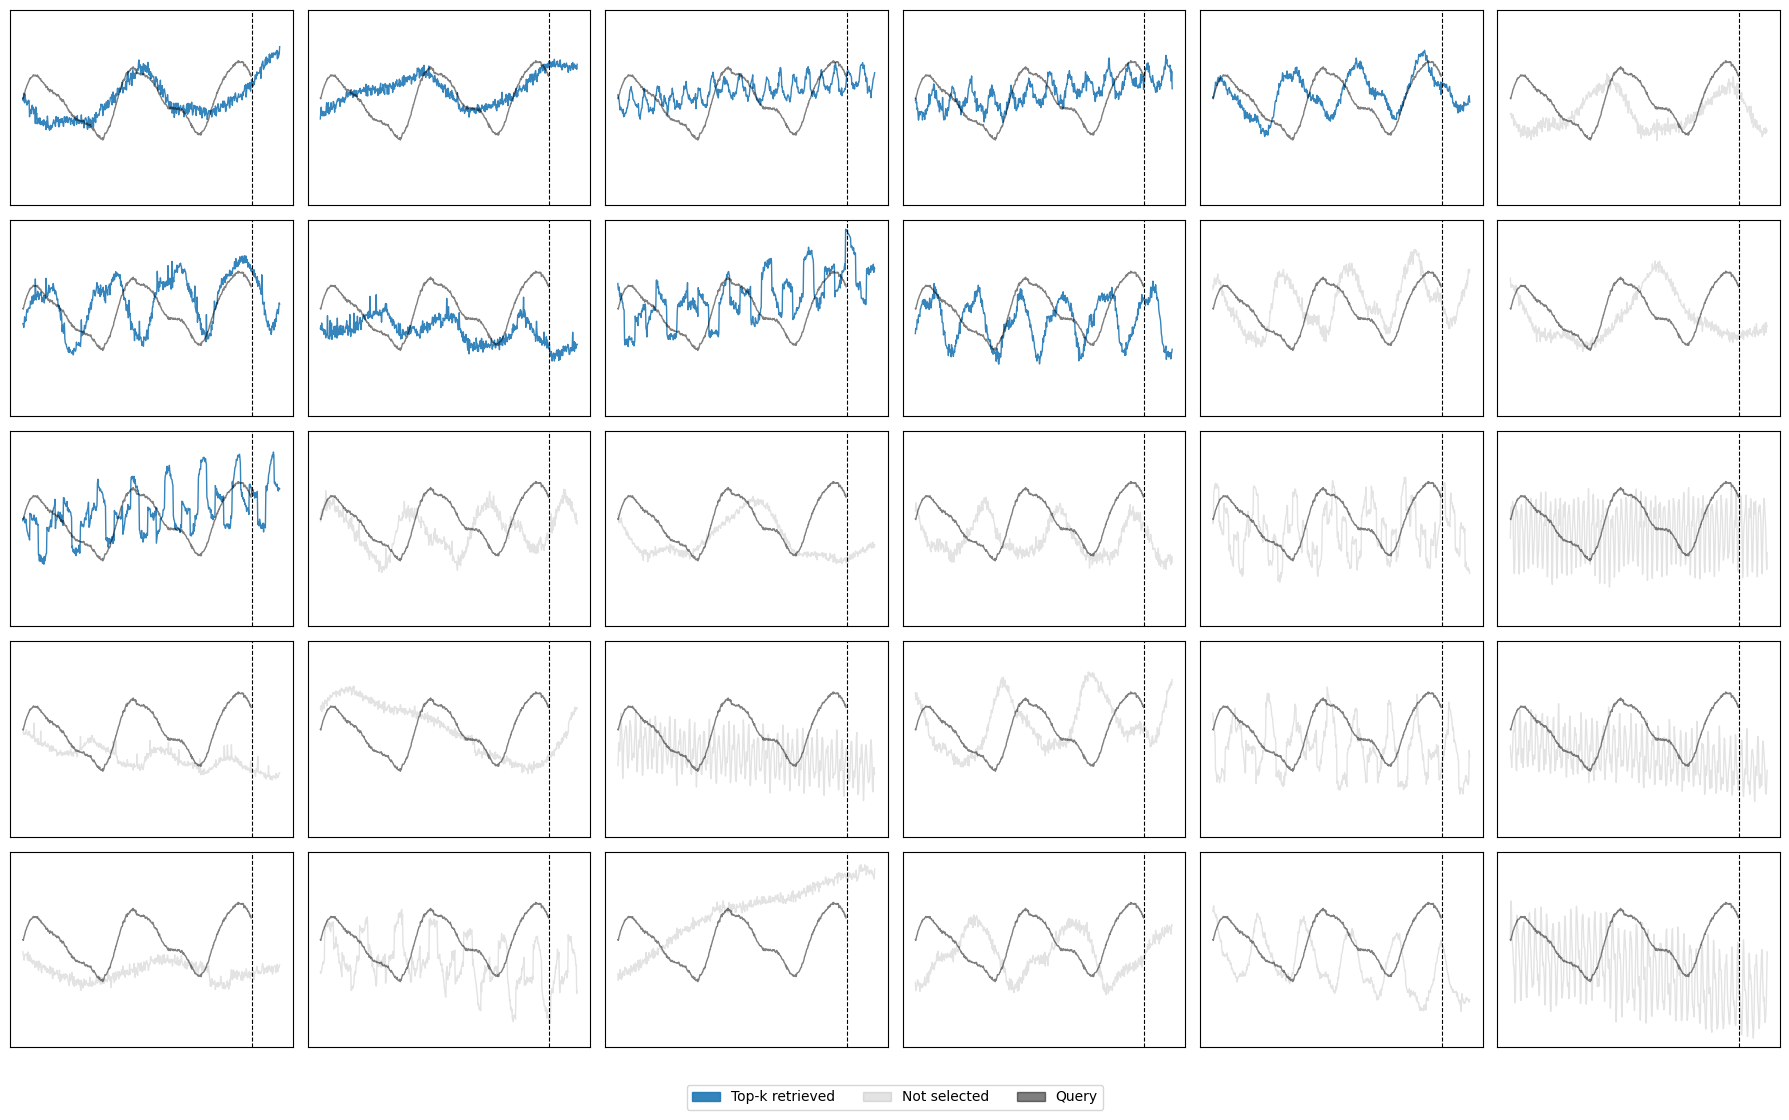

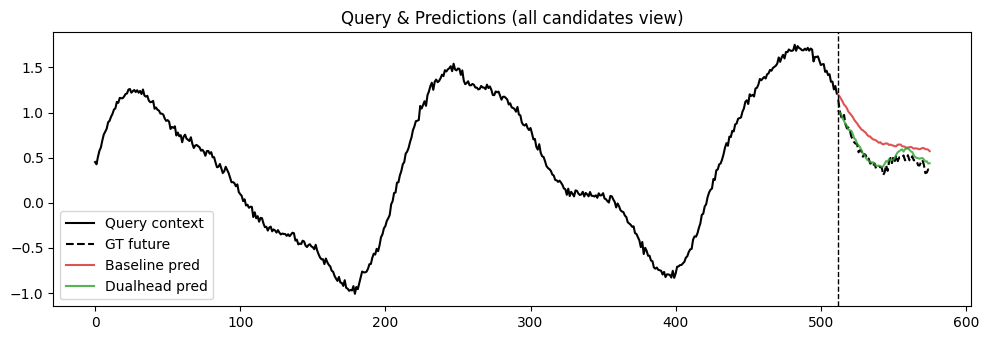

In [16]:
# Grid visualization: all candidates vs query
import matplotlib.patches as mpatches

dists_all = np.linalg.norm(retrieved[:, :context_len] - query_context[None, :], axis=1)
order = np.argsort(dists_all)  # top-left similar, bottom-right dissimilar
in_topk = np.zeros(num_candidates, dtype=bool)
in_topk[top_idx] = True

rows, cols = 5, 6  # 30 slots
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.0, rows * 2.2), sharex=True, sharey=True)
axes = axes.flatten()
top_alpha = 0.9
other_alpha = 0.22

for plot_pos, idx in enumerate(order):
    ax = axes[plot_pos]
    series = retrieved[idx]
    color = "tab:blue" if in_topk[idx] else "gray"
    alpha = top_alpha if in_topk[idx] else other_alpha
    ax.plot(series, color=color, alpha=alpha, linewidth=1.0)
    ax.plot(query_context, color="black", alpha=0.5, linewidth=1.0)
    ax.axvline(context_len, color="k", linestyle="--", linewidth=0.8)
    ax.set_xticks([])
    ax.set_yticks([])

# Legend at bottom
handles = [
    mpatches.Patch(color="tab:blue", alpha=top_alpha, label="Top-k retrieved"),
    mpatches.Patch(color="gray", alpha=other_alpha, label="Not selected"),
    mpatches.Patch(color="black", alpha=0.5, label="Query"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

# Single plot: query + predictions
plt.figure(figsize=(10, 3.5))
full_t = np.arange(context_len + pred_len)
plt.plot(full_t[:context_len], query_context, label="Query context", color="black")
plt.plot(full_t[context_len:], query_target, label="GT future", color="black", linestyle="--")
plt.plot(full_t[context_len:], base_pred, label="Baseline pred", color="tab:red", alpha=0.8)
plt.plot(full_t[context_len:], dual_pred, label="Dualhead pred", color="tab:green", alpha=0.8)
plt.axvline(context_len, color="k", linestyle="--", linewidth=1)
plt.title("Query & Predictions (all candidates view)")
plt.legend()
plt.tight_layout()
plt.show()



In [17]:
# context_len = 512
# pred_len = 64
# # retrieval control
# num_candidates = 30  # N: total pool
# k_top = 3           # K: number picked for retrieval
# k_sim_top = 3        # k: how many of the picked top_k should be similar
# k_dis_top = k_top - k_sim_top

# # Device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device


In [18]:
# # Sweep multiple synthetic seeds to find a case where dualhead >> baseline
# # We keep N, k, and mix constraints fixed; only RNG varies.

# from collections import namedtuple

# Case = namedtuple("Case", [
#     "seed", "base_mse", "dual_mse", "improve",
#     "query_context", "query_target",
#     "top_idx", "top_dists", "top_retrieved", "top_labels",
#     "retrieved", "labels",
# ])

# def build_case(seed):
#     rng_local = np.random.default_rng(seed)
#     query_full, q_freq, q_trend = make_query_series(rng_local)
#     query_context = query_full[:context_len]
#     query_target = query_full[context_len:]

#     retrieved, labels = build_candidate_bank(num_candidates, k_sim_top, k_dis_top, q_freq, q_trend, rng_local)
#     full_dists, top_idx, top_dists, top_retrieved, top_labels = enforce_topk_mix(
#         query_context, retrieved, labels, k_top, k_sim_top, rng_local
#     )

#     # tensors
#     context_t = torch.tensor(query_context, dtype=torch.float32, device=device).unsqueeze(0)
#     target_t = torch.tensor(query_target, dtype=torch.float32, device=device).unsqueeze(0)
#     mask_t = torch.ones_like(context_t)
#     target_mask_t = torch.ones_like(target_t)
#     retrieved_t = torch.tensor(top_retrieved, dtype=torch.float32, device=device).unsqueeze(0)
#     distances_t = torch.tensor(top_dists, dtype=torch.float32, device=device).unsqueeze(0)

#     base_pred, base_mse = run_model(baseline_model, context_t, target_t, mask_t, target_mask_t, retrieved_t, distances_t)
#     dual_pred, dual_mse = run_model(dualhead_model, context_t, target_t, mask_t, target_mask_t, retrieved_t, distances_t)

#     improve = base_mse - dual_mse
#     return Case(seed, base_mse, dual_mse, improve,
#                 query_context, query_target,
#                 top_idx, top_dists, top_retrieved, top_labels,
#                 retrieved, labels), base_pred, dual_pred

# best_pos = None  # cases where dualhead beats baseline
# best_pos_base_pred = None
# best_pos_dual_pred = None
# best_neg = None  # fallback if none beat baseline
# best_neg_base_pred = None
# best_neg_dual_pred = None

# for seed in range(0,1200):
#     case, bpred, dpred = build_case(seed)
#     if case.improve > 0:
#         if (best_pos is None) or (case.dual_mse < best_pos.dual_mse - 1e-6):
#             best_pos = case
#             best_pos_base_pred = bpred
#             best_pos_dual_pred = dpred
#     else:
#         if (best_neg is None) or (case.improve > best_neg.improve):
#             best_neg = case
#             best_neg_base_pred = bpred
#             best_neg_dual_pred = dpred

# if best_pos is not None:
#     best = best_pos
#     best_base_pred = best_pos_base_pred
#     best_dual_pred = best_pos_dual_pred
# else:
#     best = best_neg
#     best_base_pred = best_neg_base_pred
#     best_dual_pred = best_neg_dual_pred

# print(f"Best seed: {best.seed}, improvement (baseline - dualhead) = {best.improve:.4f}")
# print({"baseline_mse": best.base_mse, "dualhead_mse": best.dual_mse})

# # Override globals for downstream plotting
# query_context = best.query_context
# query_target = best.query_target
# top_idx = best.top_idx
# top_dists = best.top_dists
# top_retrieved = best.top_retrieved
# top_labels = best.top_labels
# retrieved = best.retrieved
# labels = best.labels
# base_pred = best_base_pred
# dual_pred = best_dual_pred

# # tensors for later reuse
# context_t = torch.tensor(query_context, dtype=torch.float32, device=device).unsqueeze(0)
# target_t = torch.tensor(query_target, dtype=torch.float32, device=device).unsqueeze(0)
# mask_t = torch.ones_like(context_t)
# target_mask_t = torch.ones_like(target_t)
# retrieved_t = torch.tensor(top_retrieved, dtype=torch.float32, device=device).unsqueeze(0)
# distances_t = torch.tensor(top_dists, dtype=torch.float32, device=device).unsqueeze(0)

# # 975, 2001

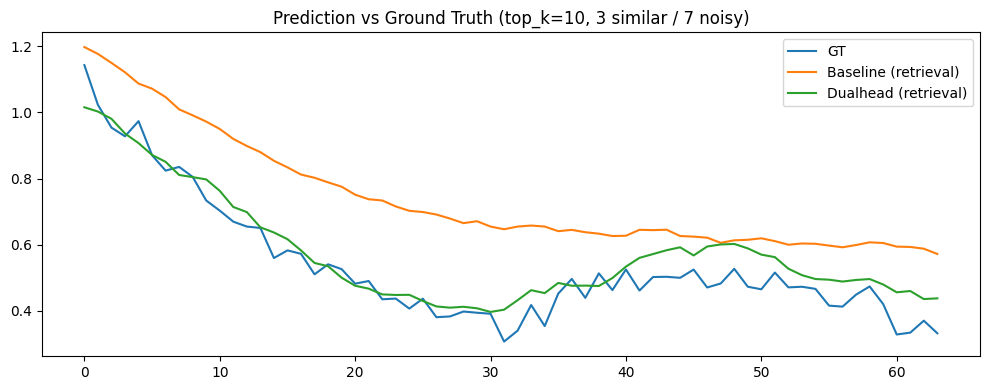

Top-10 retrieval label counts: {'dissimilar': 7, 'similar': 3}


In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
t = np.arange(pred_len)
plt.plot(t, query_target, label="GT")
plt.plot(t, base_pred, label="Baseline (retrieval)")
plt.plot(t, dual_pred, label="Dualhead (retrieval)")
plt.title("Prediction vs Ground Truth (top_k=10, 3 similar / 7 noisy)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Top-{k_top} retrieval label counts:", {k:int(v) for k,v in zip(*np.unique(top_labels, return_counts=True))})


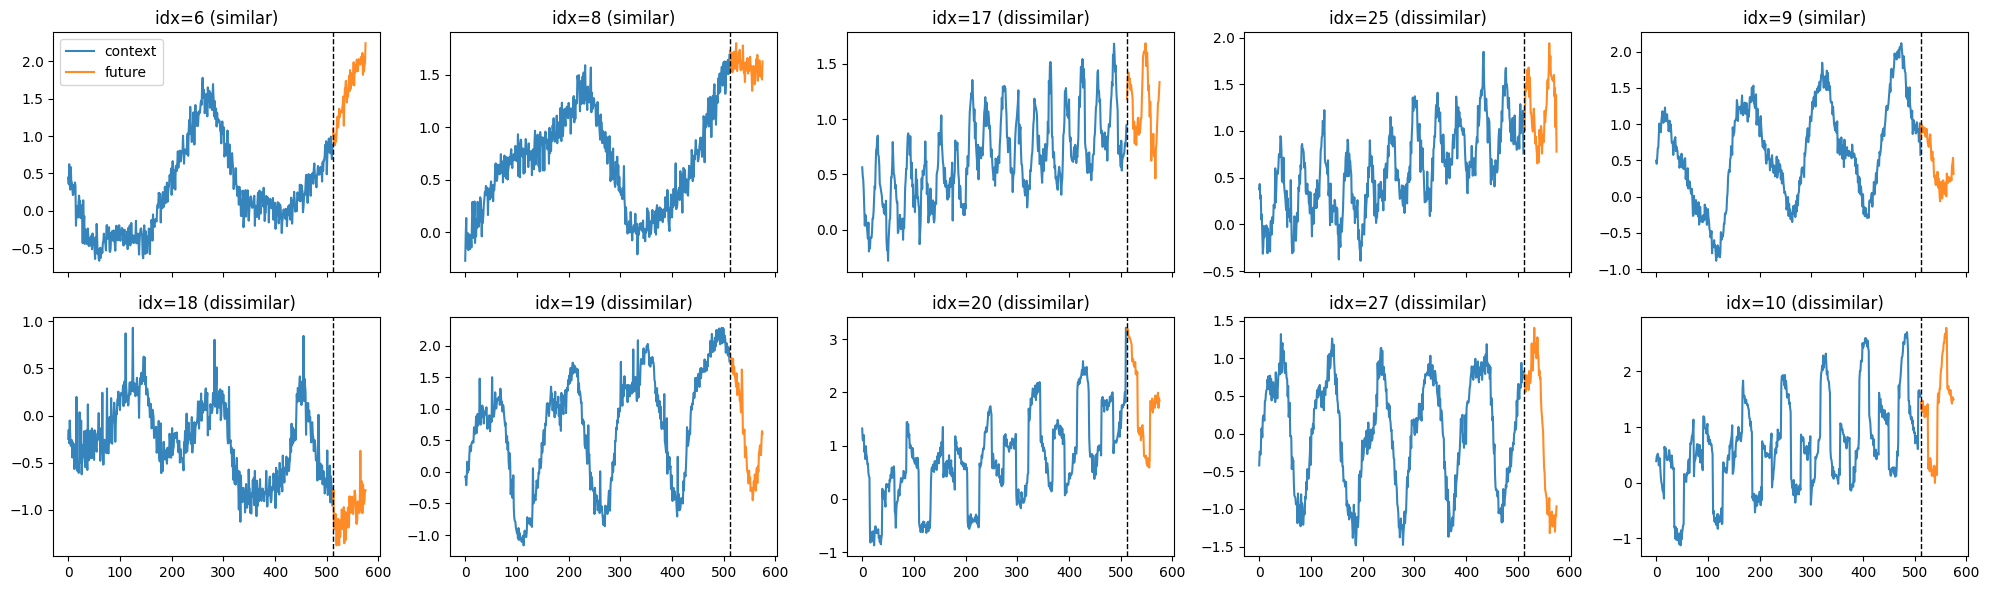

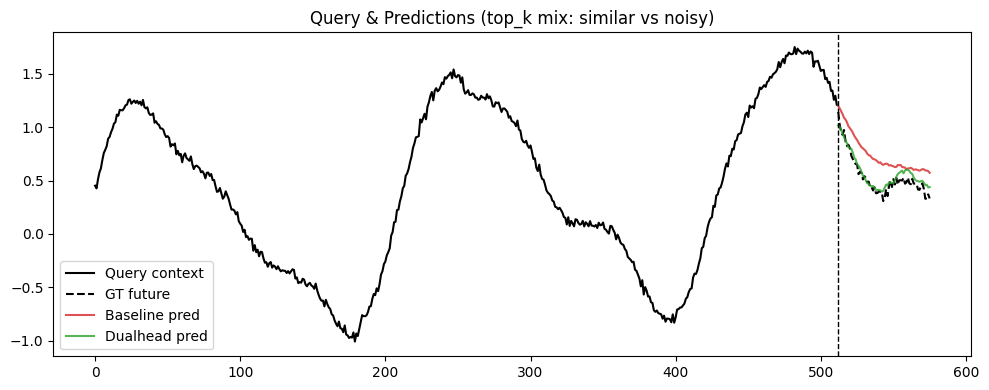

In [20]:
# Visualize retrieved top-k samples (context+future)
rows, cols = 2, (k_top + 1) // 2
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows), sharex=True)
axes = axes.flatten()
for i in range(k_top):
    ax = axes[i]
    series = top_retrieved[i]
    lbl = top_labels[i]
    ax.plot(series[:context_len], color='tab:blue', alpha=0.9, label='context')
    ax.plot(np.arange(context_len, context_len + pred_len), series[context_len:], color='tab:orange', alpha=0.9, label='future')
    ax.axvline(context_len, color='k', linestyle='--', linewidth=1)
    ax.set_title(f"idx={top_idx[i]} ({lbl})")
    if i == 0:
        ax.legend()
# hide unused axes if any
for j in range(k_top, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

# Query + predictions (baseline vs dualhead) in one view
plt.figure(figsize=(10, 4))
full_t = np.arange(context_len + pred_len)
plt.plot(full_t[:context_len], query_context, label="Query context", color="black")
plt.plot(full_t[context_len:], query_target, label="GT future", color="black", linestyle="--")
plt.plot(full_t[context_len:], base_pred, label="Baseline pred", color="tab:red", alpha=0.8)
plt.plot(full_t[context_len:], dual_pred, label="Dualhead pred", color="tab:green", alpha=0.8)
plt.axvline(context_len, color="k", linestyle="--", linewidth=1)
plt.title("Query & Predictions (top_k mix: similar vs noisy)")
plt.legend()
plt.tight_layout()
plt.show()


 

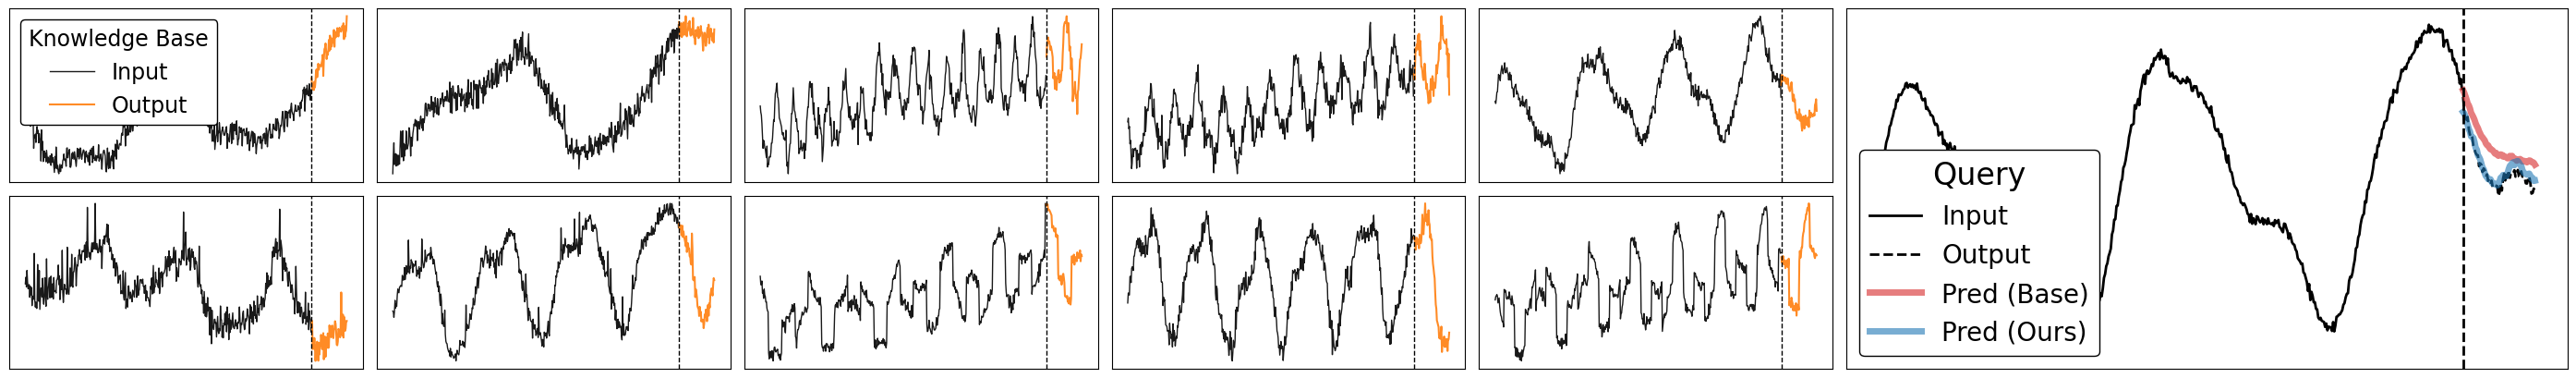

In [40]:
# Combined grid: 2x5 small panels + 2x2 main panel on the right
import matplotlib.pyplot as plt

margin_ratio = 0.05  # set your desired fraction for y-limits padding

rows_small, cols_small = 2, 5
fig = plt.figure(figsize=(4 * 7, 2.1 * 2))
gs = fig.add_gridspec(2, 7, width_ratios=[1, 1, 1, 1, 1, 1, 1])

axes_small = []
for r in range(rows_small):
    for c in range(cols_small):
        if axes_small:
            ax = fig.add_subplot(gs[r, c], sharex=axes_small[0])
        else:
            ax = fig.add_subplot(gs[r, c])
        axes_small.append(ax)

for i, ax in enumerate(axes_small):
    if i >= k_top:
        ax.axis('off')
        continue
    series = top_retrieved[i]
    lbl = top_labels[i]
#     ax.plot(series[:context_len], color='tab:blue', alpha=0.9, label='Input')
    ax.plot(series[:context_len], color='black', alpha=0.9, label='Input',lw=1)
    ax.plot(np.arange(context_len, context_len + pred_len), series[context_len:], color='tab:orange', alpha=0.9, label='Output')
    ax.axvline(context_len, color='k', linestyle='--', linewidth=1)
    ymin, ymax = series.min(), series.max()
    if ymin == ymax:
        ymin -= 0.5
        ymax += 0.5
    else:
        pad = (ymax - ymin) * margin_ratio
        ymin -= pad
        ymax += pad
    ax.set_ylim(ymin, ymax)
#     ax.set_title(f"idx={top_idx[i]} ({lbl})")
    if i == 0:
        ax.legend(
            title=r"Knowledge Base",
            title_fontsize=17,
            fontsize=17,
            loc='upper left',
            framealpha=1,
            facecolor='white',   # 배경을 흰색으로 설정
            edgecolor='black'   # 테두리를 검정색으로
        )
    ax.set_xticks([])
    ax.set_yticks([])

main_ax = fig.add_subplot(gs[:, 5:])
full_t = np.arange(context_len + pred_len)
main_ax.plot(full_t[:context_len], query_context, label="Input", color="black",lw=2)
main_ax.plot(full_t[context_len:], query_target, label="Output", color="black", linestyle="--",lw=2)
main_ax.plot(full_t[context_len:], base_pred, label="Pred (Base)", color="tab:red", alpha=0.6,lw=5)
main_ax.plot(full_t[context_len:], dual_pred, label="Pred (Ours)", color="tab:blue", alpha=0.6,lw=5)
main_ax.axvline(context_len, color="k", linestyle="--", linewidth=2)
# main_ax.set_title("Query & Predictions", fontsize=30)
#main_ax.legend(fontsize=20,loc='lower left')
main_ax.legend(
    title="Query",
    fontsize=20,
    title_fontsize=24,
    loc="lower left",
    frameon=True,
    framealpha=1,
    facecolor='white',   # 배경을 흰색으로 설정
    edgecolor='black'   # 테두리를 검정색으로
)

main_ax.set_xticks([])
main_ax.set_yticks([])

########################################################################
# plt.tight_layout()
# plt.show()
########################################################################
plt.tight_layout()
SAVE_PATH = '/home/seunghan.lee/workspace/experiments/figures'
fn = "motivation_toy.pdf"
fn = os.path.join(SAVE_PATH,fn)
plt.savefig(fn, bbox_inches="tight")
plt.show()


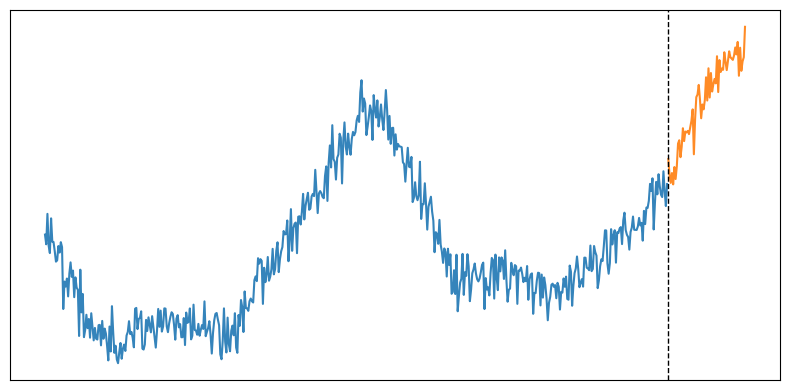

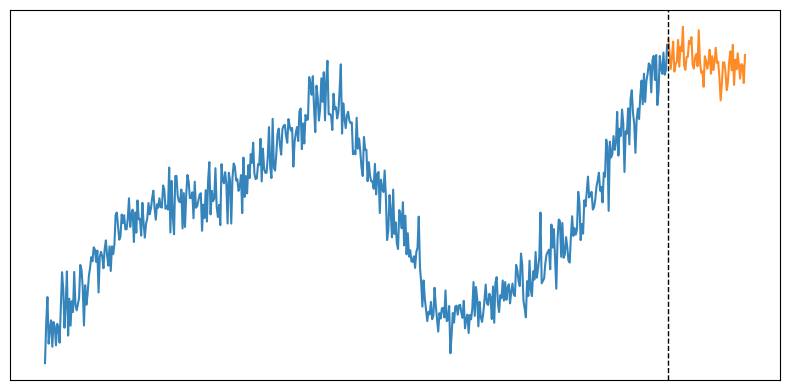

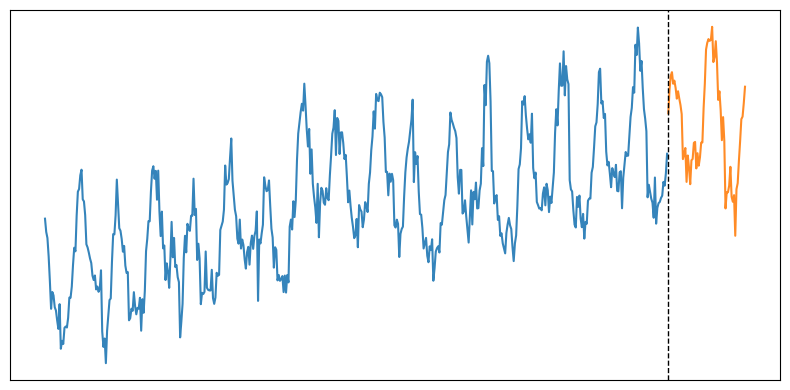

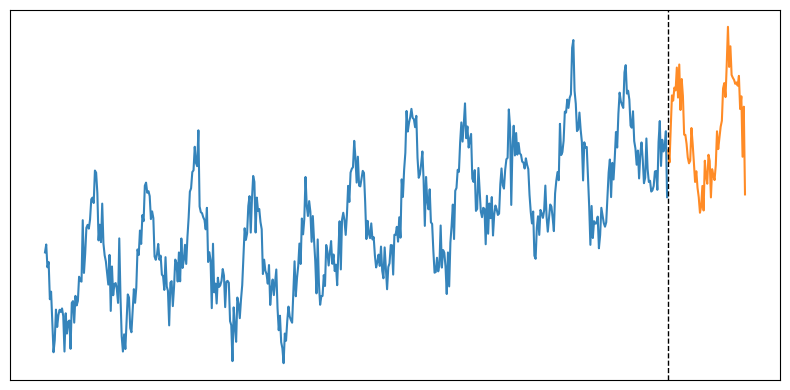

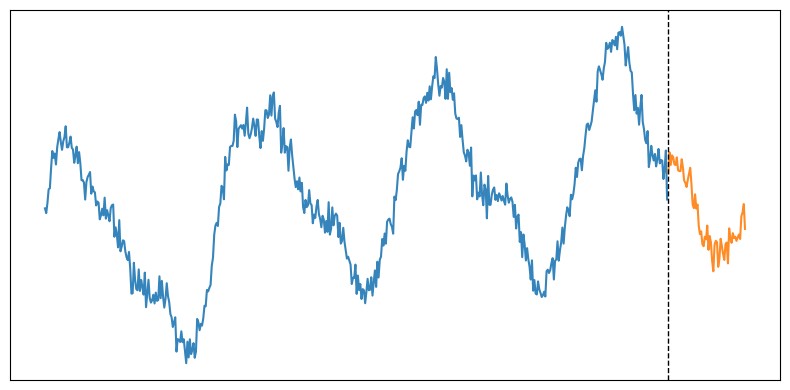

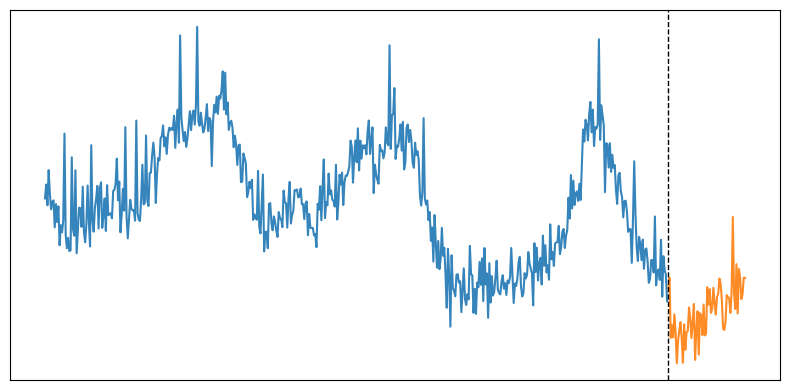

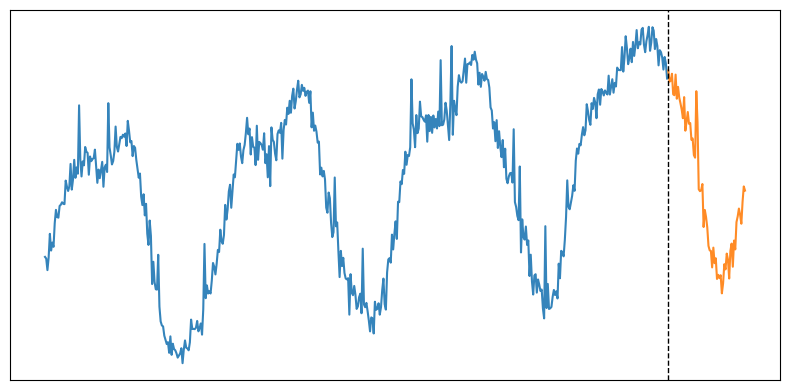

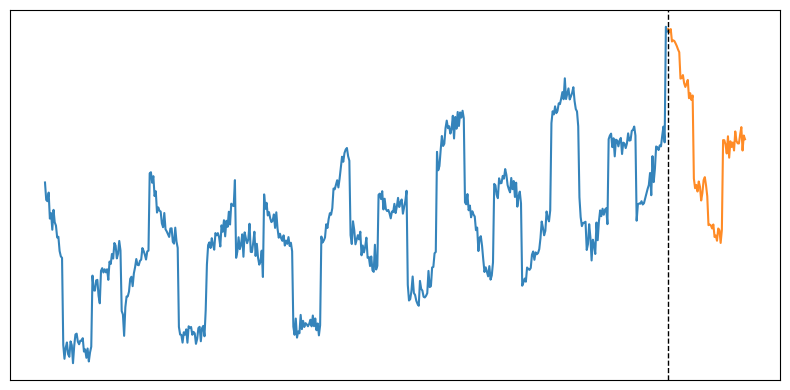

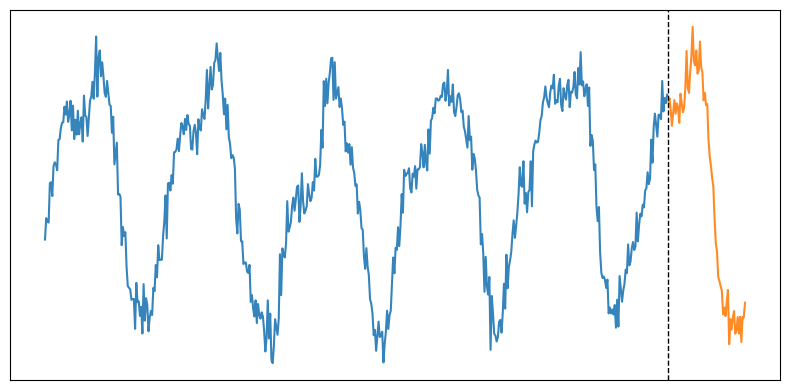

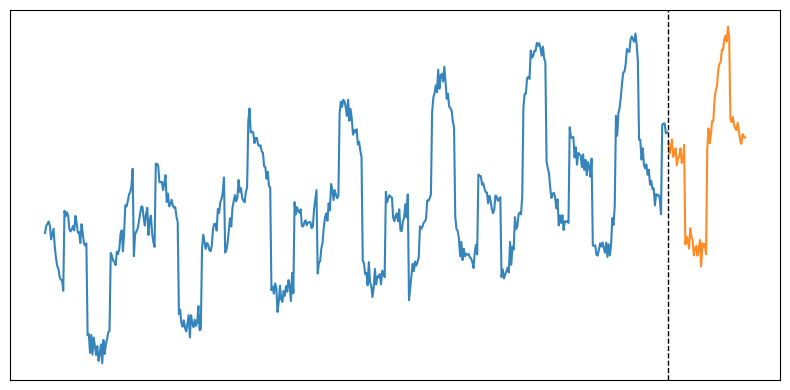

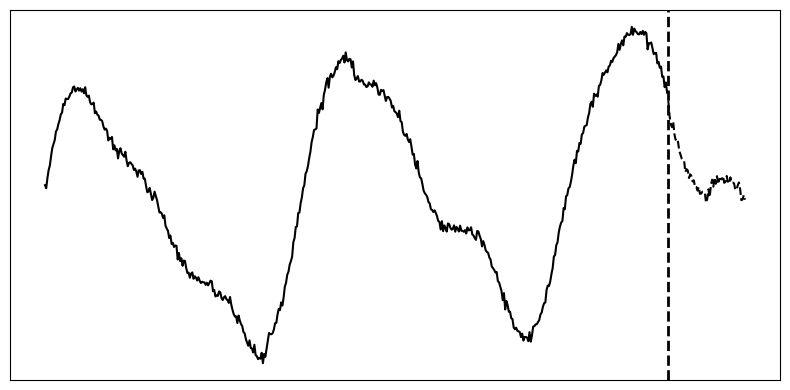

In [76]:
# Individual plots: 10 retrieval samples + 1 query
import matplotlib.pyplot as plt

margin_ratio = 0.05  # set your desired fraction for y-limits padding

# Plot 10 retrieval samples individually
for i in range(k_top):
    fig, ax = plt.subplots(figsize=(8, 4))
    series = top_retrieved[i]
    lbl = top_labels[i]
    
    ax.plot(series[:context_len], color='tab:blue', alpha=0.9)
    ax.plot(np.arange(context_len, context_len + pred_len), series[context_len:], color='tab:orange', alpha=0.9)
    ax.axvline(context_len, color='k', linestyle='--', linewidth=1)
    
    ymin, ymax = series.min(), series.max()
    if ymin == ymax:
        ymin -= 0.5
        ymax += 0.5
    else:
        pad = (ymax - ymin) * margin_ratio
        ymin -= pad
        ymax += pad
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()

# Plot query individually
fig, ax = plt.subplots(figsize=(8, 4))
full_t = np.arange(context_len + pred_len)
ax.plot(full_t[:context_len], query_context, color="black")
ax.plot(full_t[context_len:], query_target, color="black", linestyle="--")
ax.axvline(context_len, color="k", linestyle="--", linewidth=2)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()


In [77]:
import pandas as pd
df = pd.read_parquet('/home/seunghan.lee/nfs-fin/biai-onprem-pipeline/stored_data/historical/lseg/ddl/macro/2026-01-05/values_macro_indicator.parquet')

In [78]:
df

,Mnemonic,Target Date,Release Date,Value
0,BALTICF,2000-01-31,2000-01-31,1319.0000
1,BALTICF,2000-02-01,2000-02-01,1311.0000
2,BALTICF,2000-02-02,2000-02-02,1296.0000
3,BALTICF,2000-02-03,2000-02-03,1286.0000
4,BALTICF,2000-02-04,2000-02-04,1280.0000
...,...,...,...,...
560318,USGDP...D,2025-04-01,2025-07-30,23685.2870
560319,USGDP...D,2025-04-01,2025-08-28,23703.7820
560320,USGDP...D,2025-04-01,2025-09-25,23770.9760
560321,USGDP...D,2025-04-01,2025-12-23,23770.9760


In [79]:
#df[df['Mnemonic']=='USGDP...D']
# groupby releast date keep last
# 1126 -> 1000
# Domain: 10 

In [50]:
df.loc[560320].values

array(['USGDP...D', '2025-04-01', '2025-09-25', '23770.9760'],
      dtype=object)

In [51]:
df.loc[560321].values

array(['USGDP...D', '2025-04-01', '2025-12-23', '23770.9760'],
      dtype=object)

In [ ]:
# daily
# Target date
# monthly: 1/1,2/1,. 12/1
# quarterly:1/1, 4/1. 7/1, 10/1

# Release date (발표일자)
# monthly: 1/1~4/1: 4/15
# quarterly: 